In [13]:
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("dataset/tomato-yields.csv")

In [6]:
df

,Entity,Code,Year,Tomatoes | 00000388 || Yield | 005419 || tonnes per hectare
0,Africa,NaN,1961,12.320172
1,Africa,NaN,1962,12.976988
2,Africa,NaN,1963,12.867894
3,Africa,NaN,1964,13.189582
4,Africa,NaN,1965,13.492712
...,...,...,...,...
11277,Zimbabwe,ZWE,2016,7.237900
11278,Zimbabwe,ZWE,2017,7.219100
11279,Zimbabwe,ZWE,2018,7.225900
11280,Zimbabwe,ZWE,2019,7.226900


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11282 entries, 0 to 11281
Data columns (total 4 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Entity                                                       11282 non-null  object 
 1   Code                                                         8793 non-null   object 
 2   Year                                                         11282 non-null  int64  
 3   Tomatoes | 00000388 || Yield | 005419 || tonnes per hectare  11282 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 352.7+ KB


In [8]:
df.isnull().sum()

Entity                                                            0
Code                                                           2489
Year                                                              0
Tomatoes | 00000388 || Yield | 005419 || tonnes per hectare       0
dtype: int64

In [10]:
df['Entity'].value_counts()


Entity
Africa                   60
Africa (FAO)             60
Albania                  60
Algeria                  60
Americas (FAO)           60
                         ..
Maldives                 15
Serbia                   15
Serbia and Montenegro    14
Sudan                     9
Botswana                  6
Name: count, Length: 220, dtype: int64

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
11277    False
11278    False
11279    False
11280    False
11281    False
Length: 11282, dtype: bool

In [11]:
old_name = 'Tomatoes | 00000388 || Yield | 005419 || tonnes per hectare'
df.rename(columns={old_name: 'Yield'}, inplace=True)

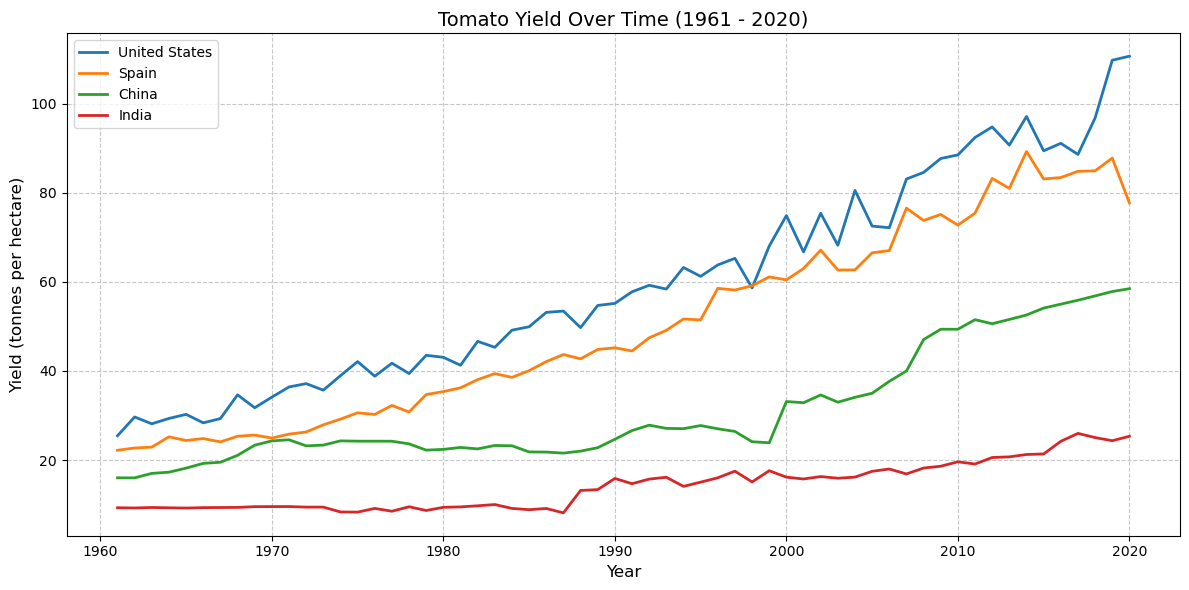

In [14]:
countries_to_plot = ["United States", "Spain", "China", "India"]
filtered_df = df[df['Entity'].isin(countries_to_plot)]

plt.figure(figsize=(12, 6))
for country in countries_to_plot:
    country_data = filtered_df[filtered_df['Entity'] == country]
    plt.plot(country_data['Year'], country_data['Yield'], label=country, linewidth=2)


plt.title('Tomato Yield Over Time (1961 - 2020)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Yield (tonnes per hectare)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()